In [32]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import settings
from src.aggregations import territorial, person, labor,cadunico, general
import pandas as pd 
import numpy as np
from pathlib import Path
import importlib

importlib.reload(settings)
importlib.reload(territorial)
importlib.reload(person)
importlib.reload(labor)
importlib.reload(cadunico)
importlib.reload(general)

pd.set_option("display.float_format", "{:,.3f}".format)
pd.set_option("display.max_columns", None)

In [ ]:
# df_cubo_old = pd.read_excel(settings.DATA_PATH /'input_data' /'dados_cubo_final_v0__2026-05-28_16-48.xlsx')

In [2]:
df_cubo = pd.read_excel(settings.DATA_PATH /'input_data' /'dados_cubo_final_v0__2026-06-10_18-44.xlsx')

In [22]:
df_cubo.head(2)

,ente,tipo_ente,tipo_documento,faixa_vlr_pago,uf,nome_ente,regiao,flag_capital,porte_populacional,Sexo,Estrangeiro,NomeNaturezaOcupacao,NomeOcupacaoPrincipal,faixa_etaria,flag_cpf_mei,cnaePrincipal,naturezaJuridica,porte,cnpj_optante_mei,raca_cor_desc_description,escolaridade_description,ind_deficiencia,tipo_deficiencia_description,tipo_vinculo_description,faixa_salarial_rais,CBO_2002_RAIS,cbo_codigo,cbo_descricao,SITUACAO,cod_situacao_nome,cod_tipo_nome,pessoaCad_cadunico,familiaPBF_cadunico,fxRendaFamiliarTotal_desc_cadunico,caracDomicilio_desc_cadunico,fxRendaPerCapita_desc_cadunico,pertence_bpc,categoria_municipio_ibge,faixa_vlr_pago_ju_bbagil,situacao_renda_cadunico,cod_cnae_principal_receita_cnpj,cnaesecundarias_receita_cnpj,descr_cnae_principal_receita_cnpj,naturezajuridica_agrupada_receita_cnpj,flag_cnae_cultural,tipo_vinculo_agregado_rais,escolaridade_agregado_rais,flag_cbo_cultural_rais,flag_join_rais,flag_cnae_educacao_receita_cnpj,flag_cnae_audiovisual_receita_cnpj,local_residencia_contemplados,quantidade,valor_transacao,min_valor_transacao,max_valor_transacao,sum_populacao
0,AC_Acre_12,ESTADO,CNPJ,1 milhão a 10 milhões,AC,Acre,Norte,False,-99,NaN,NaN,NaN,NaN,NaN,False,"{'codigo': '7820500', 'descricao': 'Locação de...","{'codigo': '2062', 'descricao': 'Sociedade Emp...",01 - MicroEmpresa-ME,0.000,NaN,NaN,NaN,NaN,NaN,NÃO SE APLICA,NaN,NaN,NaN,Urbana,Área urbana de alta densidade de edificações d...,Não especial,NaN,NaN,NaN,NaN,NaN,NaN,Capital,Acima de 200 mil,NaN,"7,820,500.000","[{'codigo': '4120400', 'descricao': 'Construçã...",Locação de mão-de-obra temporária,Microempresa-ME,CNAE NAO CULTURAL,NaN,NaN,NaN,False,CNAE NAO EDUCACAO,CNAE NAO AUDIOVISUAL,Capital,1,"2,034,002.650","2,034,002.650","2,034,002.650",880631
1,AC_Acre_12,ESTADO,CNPJ,10 a 50 mil,AC,Acre,Norte,False,-99,NaN,NaN,NaN,NaN,NaN,False,"{'codigo': '1629301', 'descricao': 'Fabricação...","{'codigo': '2135', 'descricao': 'Empresário (I...",01 - MicroEmpresa-ME,1.000,NaN,NaN,NaN,NaN,NaN,NÃO SE APLICA,NaN,NaN,NaN,Urbana,Área urbana de alta densidade de edificações d...,Não especial,NaN,NaN,NaN,NaN,NaN,NaN,Interior,De 10 a 50 mil,NaN,"1,629,301.000","[{'codigo': '4330404', 'descricao': 'Serviços ...","Fabricação de artefatos diversos de madeira, e...",MEI,CNAE NAO CULTURAL,NaN,NaN,NaN,False,CNAE NAO EDUCACAO,CNAE NAO AUDIOVISUAL,Interior,1,"50,000.000","50,000.000","50,000.000",880631


In [ ]:
# executed_value_by_porte.csv
df_porte = territorial.aggregate_recurso_municipios_por_porte(df_cubo=df_cubo)
df_porte.to_csv(settings.DATA_PATH_SECTION1 / 'executed_value_by_porte.csv')

In [ ]:
df_uf_valor = territorial.aggregate_valor_executado_por_uf_e_tipo_ente(df_cubo=df_cubo)
df_uf_valor.to_csv(settings.DATA_PATH_SECTION1 / 'special_territory_executed_value_uf.csv')

In [3]:
df_aux = pd.read_parquet(settings.DATA_PATH / 'input_data'/ 'non-public' / 'df_aux__2026-06-10_18-56.parquet')
df_aux['chave'] = df_aux["ente_bbagil"] + "-" + df_aux["documento_beneficiario_bbagil"]

# Seção 1

In [ ]:
# [Big Number] O ticket médio geral do Ciclo 1 da Política Nacional Aldir Blanc foi de R$ 12,8 mil. 
df_valor_geral = general.calcular_ticket_medio_df_aux(df_aux=df_aux)

In [17]:
# Section 1
# bignumber1.csv

# Valor executado por estado x municipio abs / percentual 
df_cubo_est = df_cubo[df_cubo['tipo_ente'] == 'ESTADO']
df_cubo_mun = df_cubo[df_cubo['tipo_ente'] == 'MUNICIPIO']

# Totais executados com ceil
valor_estados = np.ceil(df_cubo_est["valor_transacao"].sum())
valor_municipios = np.ceil(df_cubo_mun["valor_transacao"].sum())

# Valores de referência
total_estados = 1_510_000_000
total_municipios = 1_490_000_000

df_execucao = pd.DataFrame({
    "Estados_DF": [valor_estados],
    "Municipios_DF": [valor_municipios],
    "perc_executado_estados": [valor_estados / total_estados],
    "perc_executado_municipios": [valor_municipios / total_municipios],
})

df_execucao
df_execucao.to_csv('s1_bn1.csv')

In [ ]:
# executed_value_by.csv
df_states       = territorial.executed_value_n_contemplados_qty_by(df_cubo=df_cubo, by_filter='ESTADO')
df_municipality = territorial.executed_value_n_contemplados_qty_by(df_cubo=df_cubo, by_filter='MUNICIPIO')
df_uf           = territorial.executed_value_n_contemplados_qty_by(df_cubo=df_cubo, by_filter='UF')

# df_states.to_csv(settings.DATA_PATH_SECTION1 / 'executed_value_by_state.csv')
# df_municipality.to_csv(settings.DATA_PATH_SECTION1 / 'executed_value_by_municipality.csv')
# df_uf.to_csv(settings.DATA_PATH_SECTION1 / 'executed_value_by_uf.csv')

In [40]:
# resumo_valores_uf_estado.csv
df_uf_cut = territorial.criar_df_uf_cut_from_aux(df_aux=df_aux, by_filter='UF')
df_uf_cut.to_csv(settings.DATA_PATH_SECTION2 / 'resumo_valores_uf_uf.csv')

In [23]:
( df_uf_cut['valor_executado_rs'].sum()) / (df_uf_cut['qtde_contemplados'].sum())

np.float64(17053.53111699004)

In [20]:
df_uf_cut[['uf', 'media_aparada_1pct_valor', 'media_valor']].sort_values(by='media_aparada_1pct_valor', ascending=False)

,uf,media_aparada_1pct_valor,media_valor
3,DF,"85,294.542","104,760.052"
14,AM,"29,965.943","35,721.614"
20,SP,"26,023.174","33,636.456"
22,RJ,"25,915.248","32,456.702"
17,AP,"25,473.072","36,415.541"
23,ES,"23,651.241","29,596.704"
18,RR,"21,714.912","24,422.884"
24,PR,"20,920.838","25,364.101"
0,GO,"20,189.126","24,422.324"
25,RS,"18,276.764","21,370.202"


In [33]:
# aggregate_faixa_valor_ju_wide_by_uf.csv
df_uf_new = territorial.aggregate_faixa_valor_ju_wide_by_uf(df_cubo=df_cubo)
df_uf_new.to_csv(settings.DATA_PATH_SECTION2 / 'aggregate_faixa_valor_ju_wide_by_uf.csv')

In [34]:
# aggregate_faixa_valor_ju_wide_by_state.csv
df_uf_new = territorial.aggregate_faixa_valor_ju_wide_by_uf(df_cubo=df_cubo, by_filter='ESTADO')
df_uf_new.to_csv(settings.DATA_PATH_SECTION2 / 'aggregate_faixa_valor_ju_wide_by_state.csv')

In [12]:
# executed_value_by_region
df_states_region       = territorial.aggregate_execution_by_region(df_cubo=df_cubo, by_filter='ESTADO')
df_municipality_region = territorial.aggregate_execution_by_region(df_cubo=df_cubo, by_filter='MUNICIPIO')
df_uf_region           = territorial.aggregate_execution_by_region(df_cubo=df_cubo, by_filter='UF')

df_states_region.to_csv(settings.DATA_PATH_SECTION1 / 'executed_value_by_region_state.csv')
df_municipality_region.to_csv(settings.DATA_PATH_SECTION1 / 'executed_value_by_region_municipality.csv')
df_uf_region.to_csv(settings.DATA_PATH_SECTION1 / 'executed_value_by_region_uf.csv')


In [20]:
# aggregate_values_by
df_municipality_agg     = territorial.aggregate_execution_summary_by_scope(df_cubo=df_cubo, scope='MUNICIPIO')
df_state_agg            = territorial.aggregate_execution_summary_by_scope(df_cubo=df_cubo, scope='ESTADO')
df_capital_agg          = territorial.aggregate_capital_interior_summary(df_cubo=df_cubo)

df_municipality_agg.to_csv(settings.DATA_PATH_SECTION1 / 'aggregate_values_by_municipality.csv')
df_capital_agg.to_csv(settings.DATA_PATH_SECTION1 / 'aggregate_values_by_capital.csv')
df_state_agg.to_csv(settings.DATA_PATH_SECTION1 / 'aggregate_values_by_state.csv')

In [69]:
df_municipality_agg

,categoria,numero_entes,valor_total,contemplados_total,valor_total_dividido_numero_entes
0,municipios,5097,1395481268,144836,273785


In [30]:
# values_by_population_size
df_population_size = territorial.aggregate_execution_by_porte_with_estado(df_cubo=df_cubo)
denominador_urbano_rural = (
    df_population_size["valor_urbano_por_porte"]
    + df_population_size["valor_rural_por_porte"]
)

df_population_size["percentual_valor_urbano_por_porte"] = np.where(
    denominador_urbano_rural.ne(0),
    df_population_size["valor_urbano_por_porte"] / denominador_urbano_rural,
    np.nan
)

df_population_size["percentual_valor_rural_por_porte"] = np.where(
    denominador_urbano_rural.ne(0),
    df_population_size["valor_rural_por_porte"] / denominador_urbano_rural,
    np.nan
)
df_population_size.to_csv(settings.DATA_PATH_SECTION1 / 'values_by_population_size.csv')

In [79]:
df_population_size

,porte_populacional,numero_municipios,valor_total_por_porte,valor_urbano_por_porte,valor_rural_por_porte,quantidade_contemplados_por_porte,quantidade_contemplados_urbano,quantidade_contemplados_rural,1 milhão a 10 milhões,10 a 50 mil,2 a 10 mil,200 a 500 mil,50 a 200 mil,500 mil a 1 milhão,Até 2 mil,Acima de 10 milhões,qtd_tipo_documento_CNPJ,qtd_tipo_documento_CPF,valor_tipo_documento_CNPJ,valor_tipo_documento_CPF,min_valor_tipo_documento_CNPJ,min_valor_tipo_documento_CPF,mediana_valor_tipo_documento_CNPJ,mediana_valor_tipo_documento_CPF,max_valor_tipo_documento_CNPJ,max_valor_tipo_documento_CPF,media_valor_tipo_documento_CNPJ,media_valor_tipo_documento_CPF,qtd_sexo_Feminino,qtd_sexo_Masculino,valor_sexo_Feminino,valor_sexo_Masculino,total_qtd_sexo_valido,total_valor_sexo_valido,percentual_valor_urbano_por_porte,percentual_valor_rural_por_porte,percentual_valor_por_porte,percentual_quantidade_por_porte,valor_total_CPF_CNPJ,perc_valor_CPF,perc_valor_CNPJ,percentual_qtd_sexo_Feminino,percentual_qtd_sexo_Masculino,percentual_valor_sexo_Feminino,percentual_valor_sexo_Masculino
0,-99,27,"1,450,514,326.100","1,364,352,207.180","81,220,797.270",22050,20120,1843,69,11454,4479,896,4924,137,89,2,7054,14996,"937,817,660.580","512,696,665.520",965.980,429.370,"70,000.000","23,109.770","22,109,764.920","735,000.000","146,214.166","35,470.919",7101,7891,"251,685,115.660","260,854,653.860",14992,"512,539,769.520",0.944,0.056,0.510,0.132,"1,450,514,326.100",0.353,0.647,0.474,0.526,0.491,0.509
1,4_grande,332,"732,942,051.710","706,336,742.290","13,439,536.360",31255,30136,993,17,13359,12986,162,2388,22,2321,0,8191,23064,"387,614,690.420","345,327,361.290",375.000,378.000,"25,000.000","10,000.000","7,333,333.330","640,000.000","49,383.959","15,219.364",10740,12321,"157,622,640.000","187,634,471.290",23061,"345,257,111.290",0.981,0.019,0.258,0.187,"732,942,051.710",0.471,0.529,0.466,0.534,0.457,0.543
2,1_pequeno_i,3401,"266,445,332.420","226,313,098.080","39,514,920.630",57289,44350,12753,0,4511,23629,7,447,0,28695,0,9215,48074,"120,788,089.820","145,657,242.600",375.000,375.000,"6,569.900","2,000.000","437,000.000","158,500.000","13,340.854","3,136.663",23582,24492,"63,164,176.550","82,493,066.050",48074,"145,657,242.600",0.851,0.149,0.094,0.343,"266,445,332.420",0.547,0.453,0.491,0.509,0.434,0.566
3,2_pequeno_ii,1030,"234,896,275.230","204,820,059.980","29,163,318.290",38944,32136,6701,0,4424,19876,22,335,0,14287,0,4948,33996,"83,440,635.510","151,455,639.720",380.000,400.000,"10,000.000","3,000.000","345,122.000","322,558.250","17,250.493","4,617.409",15320,18672,"63,417,566.830","88,023,203.270",33992,"151,440,770.100",0.875,0.125,0.083,0.233,"234,896,275.230",0.645,0.355,0.451,0.549,0.419,0.581
4,3_medio,334,"161,197,608.530","147,500,752.720","12,718,073.400",17348,15551,1653,0,3913,9523,12,254,1,3645,0,2872,14476,"61,650,616.240","99,546,992.290",386.700,400.000,"14,040.000","5,000.000","622,055.450","150,000.000","22,232.462","7,051.069",6200,8274,"42,306,318.110","57,222,026.180",14474,"99,528,344.290",0.921,0.079,0.057,0.104,"161,197,608.530",0.618,0.382,0.428,0.572,0.425,0.575


In [23]:
# resumo_por_porte_populacional versão RESUMIDA - Estamos utilizando esse
df_resumo_por_porte_populacional = territorial.resumo_por_porte_populacional(df_aux=df_aux)
df_resumo_por_porte_populacional.to_csv(settings.DATA_PATH_SECTION2 / 'resumo_por_porte_populacional.csv')

In [14]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


def plot_boxplot_por_porte(df_resumo: pd.DataFrame) -> None:
    """
    Plota um boxplot com 4 boxes (um para cada porte populacional)
    usando as estatísticas resumidas já calculadas no df_resumo.
    """

    ordem_portes = [
        "1_pequeno_i",
        "2_pequeno_ii",
        "3_medio",
        "4_grande"
    ]

    label_map = {
        "1_pequeno_i": "Pequeno I",
        "2_pequeno_ii": "Pequeno II",
        "3_medio": "Médio",
        "4_grande": "Grande"
    }

    df_plot = df_resumo.copy()
    df_plot = (
        df_plot[df_plot["porte_populacional"].isin(ordem_portes)]
        .sort_values("porte_populacional")
        .reset_index(drop=True)
    )

    stats = []
    for _, row in df_plot.iterrows():
        stats.append({
            "label": label_map.get(row["porte_populacional"], row["porte_populacional"]),
            "whislo": row["valor_minimo_por_porte"],   # mínimo
            "q1": row["q1_valor_por_porte"],           # Q1
            "med": row["q2_valor_por_porte"],          # mediana / Q2
            "q3": row["q3_valor_por_porte"],           # Q3
            "whishi": row["valor_maximo_por_porte"],   # máximo
            "fliers": []
        })

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bxp(stats, showfliers=False)

    ax.set_title("Distribuição do valor de transação por porte populacional")
    ax.set_xlabel("Porte populacional")
    ax.set_ylabel("Valor de transação")

    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f"R$ {x:,.0f}".replace(",", "."))
    )

    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

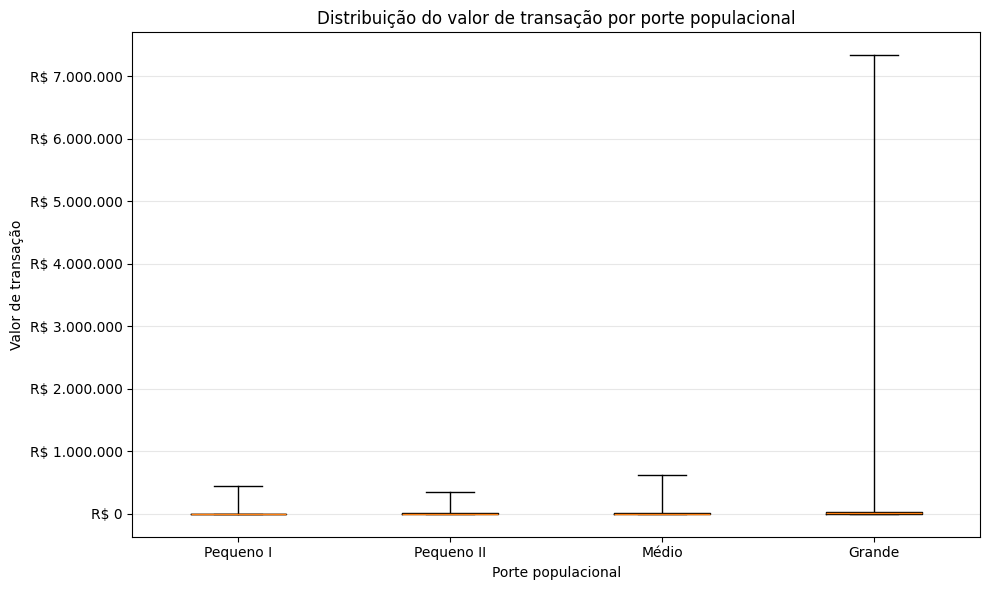

In [15]:
plot_boxplot_por_porte(df_resumo_por_porte_populacional)

In [9]:
# resumo_valor_por_porte_municipio.csv
df_population_size_mean = territorial.resumo_valor_por_porte_municipio(df_cubo=df_cubo)
# df_population_size_mean.to_csv(settings.DATA_PATH_SECTION1 / 'population_size_mean.csv')

In [10]:
df_population_size_mean

,Tipo de município,Quantidade de municípios por Porte,Valor total por Porte,Valor médio por município
0,1_pequeno_i,3401,"266,445,332.420","78,343.232"
1,2_pequeno_ii,1030,"234,896,275.230","228,054.636"
2,3_medio,334,"161,197,608.530","482,627.570"
3,4_grande,332,"732,942,051.710","2,207,656.782"


In [45]:
importlib.reload(territorial)

<module 'src.aggregations.territorial' from 'c:\\Users\\gabiru\\Documents\\GitHub\\pnab-data-vis\\src\\aggregations\\territorial.py'>

In [46]:
# values_by_special_territory
df_special_territory_municipality = territorial.aggregate_special_territories_by(
    df_cubo=df_cubo, 
    categories=settings.CATEGORIES_SPECIAL_TERRITORIES, 
    by_filter="MUNICIPIO"
)

df_special_territory_state = territorial.aggregate_special_territories_by(
    df_cubo=df_cubo, 
    categories=settings.CATEGORIES_SPECIAL_TERRITORIES, 
    by_filter="ESTADO"
)

df_special_territory_uf = territorial.aggregate_special_territories_by(
    df_cubo=df_cubo, 
    categories=settings.CATEGORIES_SPECIAL_TERRITORIES, 
    by_filter="UF"
)

df_special_territory_municipality.to_csv(settings.DATA_PATH_SECTION1 / 'values_by_special_territory_municipality.csv')
df_special_territory_state.to_csv(settings.DATA_PATH_SECTION1 / 'values_by_special_territory_state.csv')
df_special_territory_uf.to_csv(settings.DATA_PATH_SECTION1 / 'values_by_special_territory_uf.csv')


In [18]:
df_special_territory_uf

,cod_tipo_nome,valor_transacao,perc_valor_transacao,quantidade_contemplados,perc_quantidade_contemplados,qtd_tipo_documento_CNPJ,qtd_tipo_documento_CPF,valor_tipo_documento_CNPJ,valor_tipo_documento_CPF,min_valor_tipo_documento_CNPJ,min_valor_tipo_documento_CPF,mediana_valor_tipo_documento_CNPJ,mediana_valor_tipo_documento_CPF,max_valor_tipo_documento_CNPJ,max_valor_tipo_documento_CPF,media_valor_tipo_documento_CNPJ,media_valor_tipo_documento_CPF
1,Favela e Comunidade Urbana,140406774,0.049,4600,0.027,894,3706,78581958,61824816,431,400,30547,10000,22109765,400000,91057,16846
3,Agrupamento quilombola,7373210,0.003,482,0.003,72,410,3509108,3864103,1034,500,29654,3225,280000,150000,51605,9518
4,Agrupamento indígena,5078944,0.002,254,0.002,22,232,1391182,3687762,4000,500,25883,5500,250000,294095,63236,16175


In [20]:
# special_territory_w_ibge_by_brazil
df_vis_territorio_brasil = territorial.generate_special_territories_brazil_view(df_cubo=df_cubo)
# df_vis_territorio_brasil.to_csv(settings.DATA_PATH_SECTION1 / 'special_territory_w_ibge_by_brazil.csv')

In [21]:
df_vis_territorio_brasil

,territorio,Valor (R$),Quantidade de contemplados,% recurso total,% de agentes contemplados,% população no território
0,Favela e Comunidade Urbana,140406774,4600,0.050,0.030,8.000
1,Agrupamento quilombola,7373210,482,0.000,0.000,0.700
2,Agrupamento indígena,5078944,254,0.000,0.000,0.830


In [22]:
# aggregate_by_local_residencia
df_interior_rm_uf = territorial.aggregate_by_local_residencia(df_cubo=df_cubo, visao='uf')
df_interior_rm_uf.to_csv(settings.DATA_PATH_SECTION1 / 'aggregate_by_local_residencia_uf.csv')

In [ ]:
# df_interior_rm_estado
df_interior_rm_estado = territorial.aggregate_by_local_residencia(df_cubo=df_cubo, visao='estado')
df_interior_rm_estado.to_csv(settings.DATA_PATH_SECTION1 / 'aggregate_by_local_residencia_estado.csv')


In [26]:
# aggregate_estado_by_uf_local_residencia
df_interior_por_uf_estado = territorial.aggregate_estado_by_uf_local_residencia(df_cubo=df_cubo)
df_interior_por_uf_estado.to_csv(settings.DATA_PATH_SECTION1 / 'aggregate_estado_by_uf_local_residencia.csv')

# Section 2

In [80]:
#[Frase destaque] Enquanto a maior parte dos agentes culturais contemplados receberam pagamento na faixa de 2 a 10 mil reais, a maior parte do recurso executado foi para pagamentos na faixa de 10 a 50 mil reais. 
#[Gráfico] Gráfico xx - Comparativo entre Distribuição do Nº Contemplados e Distribuição de Recursos Executados (R$), por Faixa de Valor 

df_faixa_valor = territorial.aggregate_faixa_valor_ju_by(df_cubo=df_cubo)
df_faixa_valor.to_csv(settings.DATA_PATH_SECTION2 / 'values_range_by_brazil_v2.csv')
df_faixa_valor.to_csv(settings.DATA_PATH_SECTION2 / 'values_range_by_brazil.csv')


In [ ]:
# [Texto] O gráfico abaixo apresenta o comparativo entre os contemplados pela Aldir Blanc e a concentração da população em cada região do país;
# [Gráfico]  Gráfico X - Comparativo entre Distribuição dos Agentes Culturais Contemplados e Distribuição da População por Região

df_uf_region           = territorial.aggregate_execution_by_region(df_cubo=df_cubo, by_filter='UF')
# df_uf_region[['regiao', 'perc_qtde_contemplados', 'perc_populacao']]

In [ ]:
# [Texto] A distribuição de recursos nas diferentes faixas de valor permite visualizar quais regiões concentram seus recursos em pagamentos maiores - com maiores percentuais nas maiores faixas - e quais distribuiram os recursos em pagamentos menores - com destaque para a região nordeste. 
# [Gráfico]  Gráfico xx - Distribuição dos Contemplados, por Faixa de Valor Recebido, nas Regiões 

df_agg_faixas_regiao = territorial.aggregate_faixa_valor_ju_wide_by_regiao(df_cubo=df_cubo)
# df_agg_faixas_regiao[['regiao','perc_qtd_ate_2_mil', 'perc_qtd_de_2_a_10_mil', 'perc_qtd_de_10_a_50_mil', 'perc_qtd_de_50_a_200_mil', 'qtd_acima_de_200_mil']]

In [41]:
# [Texto] A partir da análise por região, percebe-se que a maioria dos contemplados recebeu pagamentos na faixa de 2 a 10 mil reais. Essa tendência é presente em todas as regiões do Brasil, com exceção do Nordeste, que registrou pagamentos de até 2 mil reais para a maioria dos contemplados (41,5%).
# [Texto] A alta presença de pagamentos até 2 mil reais na região Nordeste faz com que a região possua um ticket médio de R$ 8,2 mil, o menor entre todas as regiões.
# [Pendência: Incluir gráfico de mapa coroplético, com o ticket médio por região] 

# resumo_valores_uf_estado.csv
df_uf_cut = territorial.criar_df_uf_cut_from_aux(df_aux=df_aux, by_filter='UF')
df_uf_cut.to_csv(settings.DATA_PATH_SECTION2 / 'resumo_valores_uf.csv')

In [ ]:
def calcular_media_e_media_aparada(
    df_aux: pd.DataFrame,
    tipo_ente:str,
    coluna_valor: str = "valor_transacao_total_bbagil",
    percentual_aparado_superior: float = 0.01
) -> pd.DataFrame:
    """
    Calcula a média e a média aparada do valor recebido por contemplado.

    Considera que:
    - cada linha do DataFrame representa um contemplado;
    - a coluna de valor é `valor_transacao_total_bbagil`;
    - a média aparada remove os maiores valores, conforme o percentual definido.

    Por padrão:
    - remove os 1% maiores valores.
    """
    if tipo_ente == 'UF':
        df = df_aux.copy()
    elif tipo_ente == 'ESTADO':
        df = df_aux[df_aux["tipo_ente_bbagil"] == 'ESTADO']
    elif tipo_ente == 'MUNICIPIO':
        df = df_aux[df_aux["tipo_ente_bbagil"] == 'MUNICIPIO']
    else:
        print("tipo_ente inválido")
        return None
    df[coluna_valor] = pd.to_numeric(
        df[coluna_valor],
        errors="coerce"
    )

    serie_valor = df[coluna_valor].dropna()

    if serie_valor.empty:
        return pd.DataFrame({
            "quantidade_contemplados": [0],
            "valor_total": [np.nan],
            "valor_medio": [np.nan],
            "limite_superior_aparado": [np.nan],
            "media_aparada": [np.nan],
            "quantidade_contemplados_media_aparada": [0],
            "quantidade_removida": [0]
        })

    limite_superior = serie_valor.quantile(
        1 - percentual_aparado_superior
    )

    serie_aparada = serie_valor[serie_valor <= limite_superior]

    resultado = pd.DataFrame({
        "quantidade_contemplados": [serie_valor.count()],
        "valor_total": [serie_valor.sum()],
        "valor_medio": [serie_valor.mean()],
        "limite_superior_aparado": [limite_superior],
        "media_aparada": [serie_aparada.mean()],
        "quantidade_contemplados_media_aparada": [serie_aparada.count()],
        "quantidade_removida": [serie_valor.count() - serie_aparada.count()]
    })

    return resultado



def calcular_estatisticas_valor_por_porte_municipio(
    df_aux: pd.DataFrame,
    coluna_porte: str = "porte_populacional",
    coluna_valor: str = "valor_transacao_total_bbagil",
    coluna_tipo_ente: str = "tipo_ente_bbagil",
    percentual_aparado_superior: float = 0.01
) -> pd.DataFrame:
    """
    Calcula estatísticas do valor recebido por contemplado,
    agrupadas por porte populacional.

    Regras:
    - considera apenas tipo_ente_bbagil == 'MUNICIPIO';
    - cada linha da base representa um contemplado;
    - cada linha do resultado representa um porte populacional;
    - a média aparada remove os maiores valores dentro de cada porte.
    """

    df = df_aux.loc[
        df_aux[coluna_tipo_ente].eq("MUNICIPIO")
    ].copy()

    df[coluna_valor] = pd.to_numeric(
        df[coluna_valor],
        errors="coerce"
    )

    df = df.dropna(subset=[coluna_porte, coluna_valor])

    if df.empty:
        return pd.DataFrame(columns=[
            coluna_porte,
            "quantidade_contemplados",
            "valor_total",
            "valor_minimo",
            "quartil1",
            "mediana",
            "quartil3",
            "percentil_99",
            "valor_maximo",
            "valor_medio",
            "media_aparada"
        ])

    def calcula_grupo(grupo: pd.DataFrame) -> pd.Series:
        serie = grupo[coluna_valor].dropna()

        percentil_99 = serie.quantile(1 - percentual_aparado_superior)

        serie_aparada = serie[serie <= percentil_99]

        return pd.Series({
            "quantidade_contemplados": serie.count(),
            "valor_total": serie.sum(),
            "valor_minimo": serie.min(),
            "quartil1": serie.quantile(0.25),
            "mediana": serie.quantile(0.50),
            "quartil3": serie.quantile(0.75),
            "percentil_99": percentil_99,
            "valor_maximo": serie.max(),
            "valor_medio": serie.mean(),
            "media_aparada": serie_aparada.mean()
        })

    resultado = (
        df
        .groupby(coluna_porte, dropna=False)
        .apply(calcula_grupo)
        .reset_index()
    )

    ordem_porte = [
        "1_pequeno_i",
        "2_pequeno_ii",
        "3_medio",
        "4_grande"
    ]

    resultado["ordem"] = resultado[coluna_porte].map(
        {porte: i for i, porte in enumerate(ordem_porte)}
    )

    resultado = (
        resultado
        .sort_values("ordem")
        .drop(columns="ordem")
        .reset_index(drop=True)
    )

    return resultado


def calcular_estatisticas_valor_por_tipo_documento(
    df_aux: pd.DataFrame,
    tipo_ente: str = "UF",
    coluna_tipo_documento: str = "tipo_documento_bbagil",
    coluna_valor: str = "valor_transacao_total_bbagil",
    coluna_tipo_ente: str = "tipo_ente_bbagil",
    percentual_aparado_superior: float = 0.01,
    is_mei:str = False
) -> pd.DataFrame:
    """
    Calcula estatísticas do valor recebido por contemplado,
    agrupadas por tipo_documento_bbagil.

    Regras:
    - cada linha da base representa um contemplado;
    - cada linha do resultado representa um tipo_documento_bbagil;
    - considera apenas CPF e CNPJ;
    - tipo_ente controla o filtro:
        - 'UF': sem filtro de tipo_ente;
        - 'ESTADO': apenas tipo_ente_bbagil == 'ESTADO';
        - 'MUNICIPIO': apenas tipo_ente_bbagil == 'MUNICIPIO';
    - a média aparada remove os maiores valores dentro de cada tipo_documento_bbagil.
    """

    tipo_ente = tipo_ente.upper()

    if tipo_ente == "UF":
        df = df_aux.copy()

    elif tipo_ente in ["ESTADO", "MUNICIPIO"]:
        df = df_aux.loc[
            df_aux[coluna_tipo_ente].eq(tipo_ente)
        ].copy()

    else:
        raise ValueError("tipo_ente inválido. Use 'UF', 'ESTADO' ou 'MUNICIPIO'.")

    df[coluna_valor] = pd.to_numeric(
        df[coluna_valor],
        errors="coerce"
    )

    df = df.loc[
        df[coluna_tipo_documento].isin(["CPF", "CNPJ"])
    ].copy()

    df = df.dropna(subset=[coluna_tipo_documento, coluna_valor])

    if df.empty:
        return pd.DataFrame(columns=[
            coluna_tipo_documento,
            "quantidade_contemplados",
            "valor_total",
            "valor_minimo",
            "quartil1",
            "mediana",
            "quartil3",
            "percentil_99",
            "valor_maximo",
            "valor_medio",
            "media_aparada"
        ])

    def calcula_grupo(grupo: pd.DataFrame) -> pd.Series:
        serie = grupo[coluna_valor].dropna()

        percentil_99 = serie.quantile(
            1 - percentual_aparado_superior
        )

        serie_aparada = serie[
            serie <= percentil_99
        ]

        return pd.Series({
            "quantidade_contemplados": serie.count(),
            "valor_total": serie.sum(),
            "valor_minimo": serie.min(),
            "quartil1": serie.quantile(0.25),
            "mediana": serie.quantile(0.50),
            "quartil3": serie.quantile(0.75),
            "percentil_99": percentil_99,
            "valor_maximo": serie.max(),
            "valor_medio": serie.mean(),
            "media_aparada": serie_aparada.mean()
        })

    resultado = (
        df
        .groupby(coluna_tipo_documento, dropna=False)
        .apply(calcula_grupo)
        .reset_index()
    )

    ordem_tipo_documento = ["CPF", "CNPJ"]

    resultado["ordem"] = resultado[coluna_tipo_documento].map(
        {doc: i for i, doc in enumerate(ordem_tipo_documento)}
    )

    resultado = (
        resultado
        .sort_values("ordem")
        .drop(columns="ordem")
        .reset_index(drop=True)
    )

    return resultado

In [21]:
df_quartis_tipo_documento = calcular_estatisticas_valor_por_tipo_documento(df_aux=df_aux, tipo_ente="UF")

In [38]:
importlib.reload(territorial)

<module 'src.aggregations.territorial' from 'c:\\Users\\gabiru\\Documents\\GitHub\\pnab-data-vis\\src\\aggregations\\territorial.py'>

In [41]:
df_quartis_estados = territorial.aggregate_estatisticas_valor_por_uf(df_aux=df_aux, tipo_ente='ESTADO')

df_quartis_estados.to_csv(settings.DATA_PATH_SECTION2 / 'quartis_estados.csv')

In [43]:
df_quartis_estados['valor_total'].sum()

np.float64(1466894326.0999997)

In [17]:
df_quartis_porte = calcular_estatisticas_valor_por_porte_municipio(df_aux=df_aux)

In [18]:
df_quartis_porte

,porte_populacional,quantidade_contemplados,valor_total,valor_minimo,quartil1,mediana,quartil3,percentil_99,valor_maximo,valor_medio,media_aparada
0,1_pequeno_i,"57,292.000","266,455,633.940",375.000,"1,013.230","2,000.000","4,600.000","45,000.000","437,000.000","4,650.835","3,976.899"
1,2_pequeno_ii,"38,980.000","235,362,223.780",380.000,"1,500.000","3,000.000","6,388.253","50,000.000","345,122.000","6,038.025","5,217.057"
2,3_medio,"17,353.000","161,320,705.870",386.700,"2,500.000","5,000.000","10,000.000","60,000.000","622,055.450","9,296.416","8,257.510"
3,4_grande,"31,610.000","744,404,670.990",375.000,"5,000.000","10,980.740","25,000.000","170,000.000","7,333,333.330","23,549.657","19,385.103"


In [11]:
df_media_brasil = calcular_media_e_media_aparada(df_aux, tipo_ente='MUNICIPIO')

In [12]:
df_media_brasil

,quantidade_contemplados,valor_total,valor_medio,limite_superior_aparado,media_aparada,quantidade_contemplados_media_aparada,quantidade_removida
0,145235,"1,407,543,234.580","9,691.488","89,284.062","7,878.232",143782,1453


In [33]:
df_uf_cut['valor_executado_rs'].sum()

np.float64(2845995593.9900002)

In [34]:
df_uf_cut['qtde_contemplados'].sum()

np.int64(166886)

In [30]:
df_uf_cut['valor_executado_rs'].sum()

np.float64(2845995593.9900002)

In [ ]:
df_uf_cut[['uf','macrorregiao',	'visao','valor_executado_rs', 'qtde_contemplados']]

,uf,macrorregiao,visao,valor_executado_rs,qtde_contemplados
0,GO,Centro-Oeste,UF,"105,504,440.400",4320
1,MT,Centro-Oeste,UF,"48,393,906.410",2434
2,MS,Centro-Oeste,UF,"42,351,939.740",2188
3,DF,Centro-Oeste,UF,"41,170,700.290",393
4,BA,Nordeste,UF,"176,909,114.840",17500
5,PE,Nordeste,UF,"141,508,869.190",13472
6,CE,Nordeste,UF,"136,622,936.070",8256
7,MA,Nordeste,UF,"114,921,030.050",8366
8,PB,Nordeste,UF,"70,229,086.670",10558
9,AL,Nordeste,UF,"60,294,994.130",6378


In [35]:
# [Texto] A maioria das unidades federativas direcionaram a maior parte do recurso executado para os contemplados que receberam de 10 a 50 mil reais. 
# [Gráfico] Gráfico xx - Distribuição dos Recursos Executados nas Unidades Federativas, por Faixa de Valor 

# aggregate_faixa_valor_ju_wide_by_uf.csv
df_uf_new = territorial.aggregate_faixa_valor_ju_wide_by_uf(df_cubo=df_cubo)
df_uf_new.to_csv(settings.DATA_PATH_SECTION2 / 'aggregate_faixa_valor_ju_wide_by_uf.csv')
#df_uf_new[['uf','perc_valor_ate_2_mil', 'perc_valor_de_2_a_10_mil', 'perc_valor_de_10_a_50_mil', 'perc_valor_de_50_a_200_mil', 'perc_valor_acima_de_200_mil']]

In [37]:
# [Texto] O gráfico a seguir apresenta como os agentes culturais contemplados pelos entes estaduais foram distribuídos nas faixas de valores. Pode-se observar que a maioria recebeu valores entre 10 e 50 mil reais, o que equivale a 51,9%.
# [Gráfico] Gráfico xx - Distribuição dos contemplados, por faixa de valor, nos Estados

# aggregate_faixa_valor_ju_wide_by_state.csv
df_uf_new = territorial.aggregate_faixa_valor_ju_wide_by_uf(df_cubo=df_cubo, by_filter='ESTADO')
df_uf_new.to_csv(settings.DATA_PATH_SECTION2 / 'aggregate_faixa_valor_ju_wide_by_state.csv')

In [46]:
#[Gráfico] Gráfico xx - Distribuição dos Contemplados, por Faixa de Valor Recebido, nos Municípios por Porte de Município

# resumo_faixa_valor_por_porte.csv
df_resumo_faixas_porte = territorial.resumo_faixa_valor_por_porte(df_cubo=df_cubo)
df_resumo_faixas_porte.to_csv(settings.DATA_PATH_SECTION2 / 'faixa_valor_porte_populacional.csv')
# df_resumo_faixas_porte[['porte_populacional', 'perc_qtd_contemplados_ate_2_mil','perc_qtd_contemplados_de_2_a_10_mil','perc_qtd_contemplados_de_10_a_50_mil','perc_qtd_contemplados_de_50_a_200_mil','perc_qtd_contemplados_acima_de_200_mil', ]]

In [45]:
# [Gráfico] Gráfico xx - Distribuição dos Recursos, por Faixa de Valor, nos Municípios por Porte de Município
# resumo_faixa_valor_por_porte.csv
df_resumo_faixas_porte = territorial.resumo_faixa_valor_por_porte(df_cubo=df_cubo)
df_resumo_faixas_porte.to_csv(settings.DATA_PATH_SECTION2 / 'faixa_valor_porte_populacional.csv')
# df_resumo_faixas_porte[['porte_populacional', 'perc_valor_contemplados_ate_2_mil','perc_valor_contemplados_de_2_a_10_mil','perc_valor_contemplados_de_10_a_50_mil','perc_valor_contemplados_de_50_a_200_mil','perc_valor_contemplados_acima_de_200_mil', ]]

In [61]:
df_resumo_faixas_porte

,porte_populacional,total_qtd_contemplados,total_valor_transacao,qtd_contemplados_acima_de_200_mil,perc_qtd_contemplados_acima_de_200_mil,valor_transacao_acima_de_200_mil,perc_valor_transacao_acima_de_200_mil,qtd_contemplados_de_10_a_50_mil,perc_qtd_contemplados_de_10_a_50_mil,valor_transacao_de_10_a_50_mil,perc_valor_transacao_de_10_a_50_mil,qtd_contemplados_de_50_a_200_mil,perc_qtd_contemplados_de_50_a_200_mil,valor_transacao_de_50_a_200_mil,perc_valor_transacao_de_50_a_200_mil,qtd_contemplados_de_2_a_10_mil,perc_qtd_contemplados_de_2_a_10_mil,valor_transacao_de_2_a_10_mil,perc_valor_transacao_de_2_a_10_mil,qtd_contemplados_ate_2_mil,perc_qtd_contemplados_ate_2_mil,valor_transacao_ate_2_mil,perc_valor_transacao_ate_2_mil
0,-99,22050,"1,450,514,326.100",1104,0.050,"592,272,160.590",0.408,11454,0.519,"317,106,059.640",0.219,4924,0.223,"509,229,282.040",0.351,4479,0.203,"31,762,705.320",0.022,89,0.004,"144,118.510",0.000
1,1_pequeno_i,57289,"266,445,332.420",7,0.000,"1,796,825.730",0.007,4511,0.079,"90,736,359.520",0.341,447,0.008,"33,425,238.510",0.125,23629,0.412,"106,275,294.550",0.399,28695,0.501,"34,211,614.110",0.128
2,2_pequeno_ii,38944,"234,896,275.230",22,0.001,"5,130,439.150",0.022,4424,0.114,"82,205,026.900",0.350,335,0.009,"28,685,142.340",0.122,19876,0.510,"100,181,929.290",0.426,14287,0.367,"18,693,737.550",0.080
3,3_medio,17348,"161,197,608.530",13,0.001,"4,263,457.180",0.026,3913,0.226,"77,580,099.050",0.481,254,0.015,"20,626,727.080",0.128,9523,0.549,"53,553,579.580",0.332,3645,0.210,"5,173,745.640",0.032
4,4_grande,31255,"732,942,051.710",201,0.006,"114,515,571.730",0.156,13359,0.427,"328,691,074.040",0.448,2388,0.076,"206,663,615.150",0.282,12986,0.415,"80,044,107.450",0.109,2321,0.074,"3,027,683.340",0.004


In [28]:
df_values_by_person_type_uf = territorial.aggregate_execution_by_person_type(df_cubo=df_cubo, by_filter='UF')
df_values_by_person_type_state = territorial.aggregate_execution_by_person_type(df_cubo=df_cubo, by_filter='ESTADO')
df_values_by_person_type_municipality = territorial.aggregate_execution_by_person_type(df_cubo=df_cubo, by_filter='MUNICIPIO')

df_values_by_person_type_uf.to_csv(settings.DATA_PATH_SECTION2 / 'aggregate_execution_by_person_type_uf.csv')
df_values_by_person_type_state.to_csv(settings.DATA_PATH_SECTION2 / 'aggregate_execution_by_person_type_state.csv')
df_values_by_person_type_municipality.to_csv(settings.DATA_PATH_SECTION2 / 'aggregate_execution_by_person_type_municipality.csv')

In [27]:
df_box = territorial.make_boxplot_df_faixa_valor(df_aux=df_aux)

In [125]:
df_box

,visao,uf_bbagil,faixa_vlr_pago_ju_bbagil,metrica,valor_boxplot,unidade_observacao
0,ESTADO,AC,Até 2 mil,quantidade_contemplados,13.000,uf_faixa
1,ESTADO,AC,De 2 a 10 mil,quantidade_contemplados,25.000,uf_faixa
2,ESTADO,AC,De 10 a 50 mil,quantidade_contemplados,368.000,uf_faixa
3,ESTADO,AC,De 50 a 200 mil,quantidade_contemplados,36.000,uf_faixa
4,ESTADO,AC,Acima de 200 mil,quantidade_contemplados,10.000,uf_faixa
...,...,...,...,...,...,...
22157,ESTADO,TO,Acima de 200 mil,valor_transacao_total_bbagil,"367,000.000",contemplado
22158,ESTADO,TO,Acima de 200 mil,valor_transacao_total_bbagil,"237,000.000",contemplado
22159,ESTADO,TO,Acima de 200 mil,valor_transacao_total_bbagil,"237,000.000",contemplado
22160,ESTADO,TO,Acima de 200 mil,valor_transacao_total_bbagil,"237,000.000",contemplado


In [71]:
df_box_qtd_contemplados = df_box[df_box['metrica'] == 'quantidade_contemplados']
df_box_qtd_contemplados.to_csv(settings.DATA_PATH_SECTION2 / 'faixa_valor_box_plot_qtd_contemplados_state.csv')

In [4]:
import pandas as pd

# Filtra apenas ESTADO
df_estado = df_aux.copy()
df_estado = df_aux[df_aux['tipo_ente_bbagil'] == 'ESTADO']

# Garante que a coluna de valor está numérica
df_estado["valor_transacao_total_bbagil"] = pd.to_numeric(
    df_estado["valor_transacao_total_bbagil"],
    errors="coerce"
)

# Remove valores nulos
serie_valor = df_estado["valor_transacao_total_bbagil"].dropna()

# Limite superior para média aparada
p99 = serie_valor.quantile(0.99)

# Média aparada: remove os 1% maiores valores
media_aparada_1pct = serie_valor[serie_valor <= p99].mean()

# Tabela geral de percentis e quartis
df_percentis_estado = pd.DataFrame({
    "tipo_ente": ["GERAL"],
    "quantidade_contemplados": [serie_valor.count()],
    "valor_minimo": [serie_valor.min()],
    "p1": [serie_valor.quantile(0.01)],
    "q1": [serie_valor.quantile(0.25)],
    "q2_mediana": [serie_valor.quantile(0.50)],
    "q3": [serie_valor.quantile(0.75)],
    "p99": [p99],
    "valor_maximo": [serie_valor.max()],
    "media": [serie_valor.mean()],
    "media_aparada_1pct": [media_aparada_1pct],
    "desvio_padrao": [serie_valor.std()]
})

df_percentis_estado.to_csv(settings.DATA_PATH_SECTION2 / "quartis_estados.csv")

In [5]:
df_percentis_estado

,tipo_ente,quantidade_contemplados,valor_minimo,p1,q1,q2_mediana,q3,p99,valor_maximo,media,media_aparada_1pct,desvio_padrao
0,GERAL,22582,429.370,"2,824.000","12,500.000","30,000.000","60,000.000","500,000.000","22,109,764.920","64,958.565","52,167.462","261,668.123"


In [ ]:
df_box_qtd_contemplados = df_box[df_box['metrica'] == 'valor_t1ransacao_total_bbagil']
df_box_qtd_contemplados.to_csv(settings.DATA_PATH_SECTION2 / 'faixa_valor_box_plot_valor_transacao_total_bbagil_state.csv')

In [168]:
importlib.reload(territorial)

<module 'src.aggregations.territorial' from 'c:\\Users\\gabiru\\Documents\\GitHub\\pnab-data-vis\\src\\aggregations\\territorial.py'>

In [44]:
# resumo_faixa_valor_por_porte.csv
df_resumo_faixas_porte = territorial.resumo_faixa_valor_por_porte(df_cubo=df_cubo)
df_resumo_faixas_porte.to_csv(settings.DATA_PATH_SECTION2 / 'faixa_valor_porte_populacional.csv')

In [3]:
df_resumo_faixas_porte

NameError: name 'df_resumo_faixas_porte' is not defined

In [41]:
df_resumo_faixas_porte_cut = df_resumo_faixas_porte[df_resumo_faixas_porte['porte_populacional'] != '-99']

In [42]:
df_territorios_especiais = territorial.resumo_territorios_especiais_por_uf(df_cubo=df_cubo)
df_territorios_especiais.to_csv(settings.DATA_PATH_SECTION2 / 'territorios_especiais_por_uf.csv')

In [43]:
df_territorios_especiais = territorial.resumo_territorios_especiais_por_uf(df_cubo=df_cubo, visao='ESTADO')
df_territorios_especiais.to_csv(settings.DATA_PATH_SECTION2 / 'territorios_especiais_por_estado.csv')

In [15]:
df_agg_faixas_regiao = territorial.aggregate_faixa_valor_ju_wide_by_regiao(df_cubo=df_cubo)

In [16]:
df_agg_faixas_regiao

,regiao,total_contemplados_uf,valor_total_uf,qtd_ate_2_mil,perc_qtd_ate_2_mil,valor_ate_2_mil,perc_valor_ate_2_mil,qtd_de_2_a_10_mil,perc_qtd_de_2_a_10_mil,valor_de_2_a_10_mil,perc_valor_de_2_a_10_mil,qtd_de_10_a_50_mil,perc_qtd_de_10_a_50_mil,valor_de_10_a_50_mil,perc_valor_de_10_a_50_mil,qtd_de_50_a_200_mil,perc_qtd_de_50_a_200_mil,valor_de_50_a_200_mil,perc_valor_de_50_a_200_mil,qtd_acima_de_200_mil,perc_qtd_acima_de_200_mil,valor_acima_de_200_mil,perc_valor_acima_de_200_mil
0,Norte,14504,"303,553,050.960",3109,0.214,"4,222,896.090",0.014,6412,0.442,"34,322,684.290",0.113,4139,0.285,"100,204,251.410",0.330,753,0.052,"70,470,381.050",0.232,91,0.006,"94,332,838.120",0.311
1,Nordeste,79446,"852,268,894.220",32985,0.415,"40,446,875.550",0.047,32083,0.404,"160,070,111.710",0.188,11608,0.146,"283,494,131.220",0.333,2474,0.031,"231,025,932.590",0.271,296,0.004,"137,231,843.150",0.161
2,Centro-Oeste,9335,"237,420,986.840",1846,0.198,"2,410,110.790",0.010,4313,0.462,"23,389,777.990",0.099,2172,0.233,"55,635,914.330",0.234,864,0.093,"83,029,309.050",0.350,140,0.015,"72,955,874.680",0.307
3,Sudeste,45655,"1,066,203,024.520",8784,0.192,"11,271,956.700",0.011,19547,0.428,"106,966,998.930",0.100,13694,0.300,"317,014,751.370",0.297,2983,0.065,"285,456,080.660",0.268,647,0.014,"345,493,236.860",0.324
4,Sul,17946,"386,549,637.450",2313,0.129,"2,899,060.020",0.007,8138,0.453,"47,068,043.270",0.122,6048,0.337,"139,969,570.820",0.362,1274,0.071,"128,648,301.770",0.333,173,0.010,"67,964,661.570",0.176


In [17]:
df_regioes = territorial.resumo_por_regiao(df_aux=df_aux)
# df_regioes.to_csv(settings.DATA_PATH_SECTION2 / 'resumo_por_regiao_uf.csv')

In [18]:
df_regioes

,nome_macrorregiao,valor_total_por_regiao,valor_medio_por_regiao,valor_media_aparada_1pct_por_regiao,valor_mediano_por_regiao,quantidade_contemplados_por_regiao,percentual_valor_por_regiao,percentual_quantidade_contemplados_por_regiao,visao
0,Norte,"303,553,050.960","20,928.920","13,900.745","6,000.000",14504,0.107,0.087,UF
1,Nordeste,"852,268,894.220","10,727.650","8,222.396","3,000.000",79446,0.299,0.476,UF
2,Centro-Oeste,"237,420,986.840","25,433.421","19,403.457","5,609.610",9335,0.083,0.056,UF
3,Sudeste,"1,066,203,024.520","23,353.478","17,994.297","6,900.000",45655,0.375,0.274,UF
4,Sul,"386,549,637.450","21,539.599","17,925.222","8,822.630",17946,0.136,0.108,UF


In [67]:
# tabela_resumo_estado_municipio.csv
df_resumo_est_mun = territorial.tabela_resumo_estado_municipio(df_aux=df_aux)
df_resumo_est_mun.to_csv(settings.DATA_PATH_SECTION2 / 'tabela_resumo_estado_municipio.csv')

In [178]:
df_resumo_est_mun

,indicador,Estados,Municípios
0,Número de contemplados,22.050,144.836
1,Ticket médio dos pagamentos,R$ 52.711,R$ 7.839
2,"Concentração dos contemplados, por faixa de valor",De 10 a 50 mil,De 2 a 10 mil
3,"Concentração do recurso executado, por faixa d...",Acima de 200 mil,De 10 a 50 mil


# Section 3

In [32]:
importlib.reload(person)
importlib.reload(territorial)

<module 'src.aggregations.territorial' from 'c:\\Users\\gabiru\\Documents\\GitHub\\pnab-data-vis\\src\\aggregations\\territorial.py'>

In [206]:
# aggregate_contemplados_pf_pj_proportion.csv
df_person = person.aggregate_contemplados_pf_pj_proportion(df_cubo=df_cubo)
df_person.to_csv(settings.DATA_PATH_SECTION3 / 'aggregate_contemplados_pf_pj_proportion.csv')

In [214]:
df_person_state = person.aggregate_contemplados_pf_pj_proportion(df_cubo=df_cubo, by_filter='ESTADO')
df_person_state.to_csv(settings.DATA_PATH_SECTION3 / 'aggregate_contemplados_pf_pj_proportion_state.csv')

In [215]:
df_person_state

,quantidade_contemplados,perc_quantidade_contemplados,quantidade_contemplados_pf,perc_quantidade_contemplados_pf,quantidade_contemplados_pj,perc_quantidade_contemplados_pj,valor_contemplados,perc_valor_contemplados,valor_contemplados_pf,perc_valor_contemplados_pf,valor_contemplados_pj,perc_valor_contemplados_pj,valor_medio_contemplados_pf,media_aparada_1pct_valor_pf,valor_medio_contemplados_pj,media_aparada_1pct_valor_pj
0,22050,1.000,14996,0.680,7054,0.320,"1,450,514,326.100",1.000,"512,696,665.520",0.353,"937,817,660.580",0.647,"34,188.895","32,198.427","132,948.350","116,228.895"


In [216]:
df_person_municipio = person.aggregate_contemplados_pf_pj_proportion(df_cubo=df_cubo, by_filter='MUNICIPIO')
df_person_municipio.to_csv(settings.DATA_PATH_SECTION3 / 'aggregate_contemplados_pf_pj_proportion_municipio.csv')

In [217]:
df_person_municipio

,quantidade_contemplados,perc_quantidade_contemplados,quantidade_contemplados_pf,perc_quantidade_contemplados_pf,quantidade_contemplados_pj,perc_quantidade_contemplados_pj,valor_contemplados,perc_valor_contemplados,valor_contemplados_pf,perc_valor_contemplados_pf,valor_contemplados_pj,perc_valor_contemplados_pj,valor_medio_contemplados_pf,media_aparada_1pct_valor_pf,valor_medio_contemplados_pj,media_aparada_1pct_valor_pj
0,144836,1.000,119610,0.826,25226,0.174,"1,395,481,267.890",1.000,"741,987,235.900",0.532,"653,494,031.990",0.468,"6,203.388","5,815.302","25,905.575","21,525.165"


In [ ]:
# aggregate_cnpj_mei_proportion.csv
df_person_mei = person.aggregate_cnpj_mei_proportion(df_cubo=df_cubo)
df_person_mei.to_csv(settings.DATA_PATH_SECTION3 / 'aggregate_cnpj_mei_proportion.csv')

In [212]:
df_person_mei

,quantidade_contemplados_cnpj,perc_quantidade_contemplados_cnpj,quantidade_contemplados_mei,perc_quantidade_contemplados_mei,quantidade_contemplados_nao_mei,perc_quantidade_contemplados_nao_mei,valor_contemplados_cnpj,perc_valor_contemplados_cnpj,valor_contemplados_mei,perc_valor_contemplados_mei,valor_contemplados_nao_mei,perc_valor_contemplados_nao_mei,valor_medio_contemplados_cnpj,valor_medio_contemplados_mei,valor_medio_contemplados_nao_mei,media_aparada_1pct_valor_cnpj,media_aparada_1pct_valor_mei,media_aparada_1pct_valor_nao_mei
0,32280,1.000,9076,0.281,23204,0.719,"1,591,311,692.570",1.000,"238,855,895.500",0.150,"1,352,455,797.070",0.850,"49,297.140","26,317.309","58,285.459","38,847.488","23,149.502","45,678.340"


In [196]:
df_cubo_cnpj = df_cubo[df_cubo['tipo_documento']=='CNPJ']

In [198]:
df_cubo_cnpj['valor_transacao'].sum()

np.float64(1591311692.5700002)

In [ ]:
df_cubo_mei = df_cubo[df_cubo['cnpj_optante_mei']==1]

In [195]:
df_cubo_cnpj['valor_transacao'].sum()

np.float64(238855895.5)

0.15010000656392022

In [49]:
# aggregate_contemplados_by_sexo_proportion.csv
df_sexo = person.aggregate_contemplados_by_sexo_proportion(df_cubo=df_cubo)
df_sexo.to_csv(settings.DATA_PATH_SECTION3 / 'aggregate_contemplados_by_sexo_proportion.csv')

In [25]:
df_sexo

,quantidade_contemplados,perc_quantidade_contemplados,valor_contemplados,perc_valor_contemplados,valor_medio_contemplados,valor_medio_aparado_contemplados,quantidade_contemplados_feminino,perc_quantidade_contemplados_feminino,valor_contemplados_feminino,perc_valor_contemplados_feminino,valor_medio_contemplados_feminino,valor_medio_aparado_contemplados_feminino,quantidade_contemplados_masculino,perc_quantidade_contemplados_masculino,valor_contemplados_masculino,perc_valor_contemplados_masculino,valor_medio_contemplados_masculino,valor_medio_aparado_contemplados_masculino
0,134593,1,"1,254,423,237.800",1,"9,320.122","7,913.094",62943,0.468,"578,195,817.150",0.461,"9,186.023","7,953.067",71650,0.532,"676,227,420.650",0.539,"9,437.926","8,075.165"


In [47]:
# aggregate_valor_quantity_by_age_group_sexo_wide
df_age_group = person.aggregate_valor_quantity_by_age_group_sexo_wide(df_cubo=df_cubo)
df_age_group.to_csv(settings.DATA_PATH_SECTION3 / 'aggregate_valor_quantity_by_age_group_sexo_wide.csv')

In [6]:
df_age_group

sexo_tratado,faixa_etaria,valor_recebido_feminino,valor_recebido_masculino,valor_recebido_total,perc_valor_feminino_na_faixa,perc_valor_masculino_na_faixa,perc_valor_total_geral,quantidade_contemplados_feminino,quantidade_contemplados_masculino,quantidade_contemplados_total,perc_quantidade_feminino_na_faixa,perc_quantidade_masculino_na_faixa,perc_quantidade_total_geral
0,15-24 anos,36202863,37636414,73839277,0.490,0.510,0.059,4964,5844,10808,0.459,0.541,0.080
1,25-54 anos,419474838,516425879,935900716,0.448,0.552,0.746,42394,52559,94953,0.446,0.554,0.705
2,55-64 anos,75062775,70779785,145842560,0.515,0.485,0.116,9565,7653,17218,0.556,0.444,0.128
3,65+ anos,47455343,51385344,98840686,0.480,0.520,0.079,6020,5594,11614,0.518,0.482,0.086


In [48]:
# aggregate_value_quantity_by_age_group_region_wide
df_age_region = person.aggregate_value_quantity_by_age_group_region_wide(df_cubo=df_cubo)
df_age_region.to_csv(settings.DATA_PATH_SECTION3 / 'aggregate_value_quantity_by_age_group_region_wide.csv')

In [54]:
# aggregate_sexo_uf_ibge_pnab.csv
df_resumo_sexo = person.aggregate_sexo_uf_ibge_pnab(df_cubo=df_cubo)
df_resumo_sexo.to_csv(settings.DATA_PATH_SECTION3 / 'aggregate_sexo_uf_ibge_pnab.csv')


In [55]:
df_porte_sexo = territorial.aggregate_execution_by_porte_with_estado_sexo(df_cubo=df_cubo)
df_porte_sexo.to_csv(settings.DATA_PATH_SECTION3 / 'values_by_population_size_v2.csv')


In [53]:
df_cnpj_natureza = person.aggregate_cnpj_natureza_juridica(df_cubo=df_cubo)
df_cnpj_natureza.to_csv(settings.DATA_PATH_SECTION3 / 'aggregate_cnpj_natureza_juridica.csv')

In [52]:
df_cnpj_natureza_regiao = person.aggregate_cnpj_natureza_juridica_por_regiao(df_cubo=df_cubo)
df_cnpj_natureza_regiao.to_csv(settings.DATA_PATH_SECTION3 / 'aggregate_cnpj_natureza_juridica_por_regiao.csv')

In [85]:
df_cnpj_natureza_regiao[['regiao', 'natureza_juridica', 'perc_quantidade_contemplados_na_regiao']]

,regiao,natureza_juridica,perc_quantidade_contemplados_na_regiao
0,Norte,Microempresa-ME,0.260
1,Norte,MEI,0.171
2,Norte,Empresa de Pequeno Porte (EPP),0.084
3,Norte,Administração Pública,0.006
4,Norte,Entidades sem fins lucrativos,0.466
5,Norte,Entidades Empresariais,0.014
6,Nordeste,Microempresa-ME,0.282
7,Nordeste,MEI,0.249
8,Nordeste,Empresa de Pequeno Porte (EPP),0.062
9,Nordeste,Administração Pública,0.003


In [248]:
importlib.reload(person)

<module 'src.aggregations.person' from 'c:\\Users\\gabiru\\Documents\\GitHub\\pnab-data-vis\\src\\aggregations\\person.py'>

In [63]:
df_cnae_principal = person.top_cnaes_cnpj(df_cubo=df_cubo, apenas_cnae_cultural=False)
df_cnae_principal.to_csv(settings.DATA_PATH_SECTION3 / 'top_cnaes_cnpj.csv')

In [51]:
df_cnae_principal_cultura = person.top_cnaes_cnpj(df_cubo=df_cubo, apenas_cnae_cultural=True)
df_cnae_principal_cultura.to_csv(settings.DATA_PATH_SECTION3 / 'top_cnaes_cnpj_cultura.csv')

In [33]:
df_capital_sexo = person.make_df_media_aparada_sexo_capitais_cpf(df_cubo=df_cubo)

In [35]:
df_capital_sexo

,Sexo,quantidade_contemplados,valor_contemplados,valor_medio,valor_medio_aparado
0,Feminino,1867,"43,752,418.790","23,434.611","22,493.101"
1,Masculino,2087,"51,419,814.930","24,638.148","23,952.942"


# Section 4

In [66]:
importlib.reload(labor)
importlib.reload(person)


<module 'src.aggregations.person' from 'c:\\Users\\gabiru\\Documents\\GitHub\\pnab-data-vis\\src\\aggregations\\person.py'>

In [56]:
# aggregate_vinculo_formal_labor.csv
df_not_in_mercado = labor.aggregate_vinculo_formal_labor(df_cubo=df_cubo)
df_not_in_mercado.to_csv(settings.DATA_PATH_SECTION4 / 'aggregate_vinculo_formal_labor.csv')

In [258]:
df_not_in_mercado

,numero_contemplados_sem_vinculo_trabalho_formal,numero_contemplados_com_vinculo_trabalho_formal,numero_contemplados_total,percentual_contemplados_sem_vinculo_trabalho_formal,percentual_contemplados_com_vinculo_trabalho_formal,valor_pago_sem_vinculo_trabalho_formal,valor_pago_com_vinculo_trabalho_formal,valor_pago_total,percentual_valor_pago_sem_vinculo_trabalho_formal,percentual_valor_pago_com_vinculo_trabalho_formal
0,74696,59910,134606,0.555,0.445,"649,385,460.010","605,298,441.410","1,254,683,901.420",0.518,0.482


In [67]:
# aggregate_vinculo_formal_labor_by_uf.csv
df_not_in_mercado_by_uf = labor.aggregate_vinculo_formal_labor_by_uf(df_cubo=df_cubo)
df_not_in_mercado_by_uf.to_csv(settings.DATA_PATH_SECTION4 / 'aggregate_vinculo_formal_labor_by_uf.csv')

In [68]:
# aggregate_vinculo_formal_labor_by_uf_ibge.csv
# percentual_numero_contemplados_com_vinculo_no_total_brasil
df_rais_ibge = person.aggregate_vinculo_formal_labor_by_uf(
    df_cubo=df_cubo
)

df_rais_ibge.to_csv(settings.DATA_PATH_SECTION4 / 'aggregate_vinculo_formal_labor_by_uf_ibge.csv')

TypeError: aggregate_vinculo_formal_labor_by_uf() missing 1 required positional argument: 'df_rais_uf'

In [31]:
df_rais_ibge

,uf,codigo_uf,unidade_da_federacao,populacao_ibge_2024,total_vinculos_a_rais_2024,percentual_populacao_com_vinculo_rais_2024,numero_contemplados_sem_vinculo_trabalho_formal,numero_contemplados_com_vinculo_trabalho_formal,numero_contemplados_total,percentual_contemplados_sem_vinculo_trabalho_formal,percentual_contemplados_com_vinculo_trabalho_formal,diferenca_pp_contemplados_com_vinculo_vs_populacao_uf,razao_contemplados_com_vinculo_vs_populacao_uf,percentual_numero_contemplados_no_total_geral,percentual_numero_contemplados_sem_vinculo_no_total_geral,percentual_numero_contemplados_com_vinculo_no_total_geral,valor_pago_sem_vinculo_trabalho_formal,valor_pago_com_vinculo_trabalho_formal,valor_pago_total,percentual_valor_pago_sem_vinculo_trabalho_formal,percentual_valor_pago_com_vinculo_trabalho_formal,percentual_valor_pago_no_total_geral,percentual_valor_pago_sem_vinculo_no_total_geral,percentual_valor_pago_com_vinculo_no_total_geral
0,AC,12,Acre,880631,180093,0.205,414.000,544.000,958.000,0.432,0.568,0.363,2.777,0.007,0.006,0.009,"6,029,226.360","8,393,534.760","14,422,761.120",0.418,0.582,0.011,0.009,0.014
1,AL,27,Alagoas,3220104,636259,0.198,"2,943.000","2,743.000","5,686.000",0.518,0.482,0.285,2.441,0.042,0.039,0.046,"15,522,910.730","17,571,027.770","33,093,938.500",0.469,0.531,0.026,0.024,0.029
2,AM,13,Amazonas,4281209,801349,0.187,830.000,875.000,"1,705.000",0.487,0.513,0.326,2.742,0.013,0.011,0.015,"22,207,375.410","20,924,331.920","43,131,707.330",0.515,0.485,0.034,0.034,0.035
3,AP,16,Amapá,802837,154926,0.193,228.000,297.000,525.000,0.434,0.566,0.373,2.932,0.004,0.003,0.005,"2,267,715.500","2,983,510.950","5,251,226.450",0.432,0.568,0.004,0.003,0.005
4,BA,29,Bahia,14850513,2774157,0.187,"8,964.000","6,749.000","15,713.000",0.570,0.430,0.243,2.299,0.117,0.120,0.113,"54,432,147.090","49,256,473.830","103,688,620.920",0.525,0.475,0.083,0.084,0.081
5,CE,23,Ceará,9233656,1871093,0.203,"4,271.000","3,147.000","7,418.000",0.576,0.424,0.222,2.094,0.055,0.057,0.053,"38,868,061.770","36,801,043.890","75,669,105.660",0.514,0.486,0.060,0.060,0.061
6,DF,53,Distrito Federal,2982818,1707305,0.572,174.000,121.000,295.000,0.590,0.410,-0.162,0.717,0.002,0.002,0.002,"5,995,132.440","3,743,567.140","9,738,699.580",0.616,0.384,0.008,0.009,0.006
7,ES,32,Espírito Santo,4102129,1101019,0.268,418.000,508.000,926.000,0.451,0.549,0.280,2.044,0.007,0.006,0.008,"6,648,941.860","7,627,382.160","14,276,324.020",0.466,0.534,0.011,0.010,0.013
8,GO,52,Goiás,7350483,1950312,0.265,"1,828.000","1,701.000","3,529.000",0.518,0.482,0.217,1.817,0.026,0.024,0.028,"33,130,113.390","30,021,027.510","63,151,140.900",0.525,0.475,0.050,0.051,0.050
9,MA,21,Maranhão,7010960,977685,0.139,"4,551.000","2,913.000","7,464.000",0.610,0.390,0.251,2.799,0.055,0.061,0.049,"23,193,784.490","21,275,349.840","44,469,134.330",0.522,0.478,0.035,0.036,0.035


In [59]:
# aggregate_vinculo_formal_labor_by_region.csv
df_not_in_mercado_by_region = labor.aggregate_vinculo_formal_labor_by_region(df_cubo=df_cubo)
df_not_in_mercado_by_region.to_csv(settings.DATA_PATH_SECTION4 / 'aggregate_vinculo_formal_labor_by_region.csv')


In [60]:
# aggregate_vinculo_formal_labor_by_sexo.csv
df_not_in_mercado_by_sexo = labor.aggregate_vinculo_formal_labor_by_sexo(df_cubo=df_cubo)
df_not_in_mercado_by_sexo.to_csv(settings.DATA_PATH_SECTION4 / 'aggregate_vinculo_formal_labor_by_sexo.csv')

In [57]:
# aggregate_vinculo_formal_labor_by_age_group.csv
df_not_in_mercado_by_age_group = labor.aggregate_vinculo_formal_labor_by_age_group(df_cubo=df_cubo)
df_not_in_mercado_by_age_group.to_csv(settings.DATA_PATH_SECTION4 / 'aggregate_vinculo_formal_labor_by_age_group.csv')

In [63]:
# aggregate_vinculo_formal_labor_by_raca_cor.csv
df_not_in_mercado_by_raca_cor = labor.aggregate_vinculo_formal_labor_by_raca_cor(df_cubo=df_cubo)
df_not_in_mercado_by_raca_cor.to_csv(settings.DATA_PATH_SECTION4 / 'aggregate_vinculo_formal_labor_by_raca_cor.csv')


In [62]:
# resumo_raca_cor_com_vinculo_rais.csv
df_raca_cor_att = labor.resumo_raca_cor_com_vinculo_rais(df_cubo=df_cubo)
df_raca_cor_att.to_csv(settings.DATA_PATH_SECTION4 / 'resumo_raca_cor_com_vinculo_rais.csv')


In [5]:
# resumo_escolaridade_com_vinculo_rais.csv
df_escolaridade = labor.resumo_escolaridade_com_vinculo_rais(df_cubo=df_cubo)
df_escolaridade.to_csv(settings.DATA_PATH_SECTION4 / 'resumo_escolaridade_com_vinculo_rais.csv')

In [4]:
df_escolaridade

,escolaridade_agregado_rais,qtd_contemplados_com_vinculo,valor_transacao_com_vinculo,perc_qtd_contemplados_com_vinculo,perc_valor_transacao_com_vinculo,valor_medio_transacao_com_vinculo
0,Sem instrução e fundamental incompleto,2214,"12,610,139.430",3.696,2.083,"5,695.637"
1,Fundamental completo e médio incompleto,3709,"24,609,957.200",6.191,4.066,"6,635.200"
2,Médio completo e superior incompleto,26515,"220,888,798.510",44.258,36.493,"8,330.711"
3,Superior completo,25545,"311,525,984.680",42.639,51.467,"12,195.184"
4,Mestrado ou doutorado completo,1927,"35,663,561.590",3.216,5.892,"18,507.297"


In [10]:
df_cubo[df_cubo['raca_cor_desc_description'] == 'Parda – para a pessoa que se enquadrar como parda ou se declarar como mulata, cabocla, cafuza, mameluca ou mestiça de preto com pessoa de outra cor ou raça.']['quantidade'].sum()

np.int64(27071)

In [64]:
# aggregate_raca_cor_vinculo_formal_labor_by_sexo
df_not_in_mercado_by_raca_cor_sexo = labor.aggregate_raca_cor_vinculo_formal_labor_by_sexo(df_cubo=df_cubo)
df_not_in_mercado_by_raca_cor_sexo.to_csv(settings.DATA_PATH_SECTION4 / 'aggregate_raca_cor_vinculo_formal_labor_by_sexo.csv')

In [88]:
# aggregate_vinculo_formal_labor_by_escolaridade.csv
df_not_in_mercado_escolaridade = labor.aggregate_vinculo_formal_labor_by_escolaridade(df_cubo=df_cubo)
# df_not_in_mercado_escolaridade.to_csv(settings.DATA_PATH_SECTION4 / 'aggregate_vinculo_formal_labor_by_escolaridade.csv')

In [89]:
df_not_in_mercado_escolaridade

,escolaridade_agregado_rais,numero_contemplados_sem_vinculo_trabalho_formal,numero_contemplados_com_vinculo_trabalho_formal,numero_contemplados_total,percentual_contemplados_sem_vinculo_trabalho_formal,percentual_contemplados_com_vinculo_trabalho_formal,percentual_numero_contemplados_no_total_geral,percentual_numero_contemplados_sem_vinculo_no_total_geral,percentual_numero_contemplados_com_vinculo_no_total_geral,valor_pago_sem_vinculo_trabalho_formal,valor_pago_com_vinculo_trabalho_formal,valor_pago_total,percentual_valor_pago_sem_vinculo_trabalho_formal,percentual_valor_pago_com_vinculo_trabalho_formal,percentual_valor_pago_no_total_geral,percentual_valor_pago_sem_vinculo_no_total_geral,percentual_valor_pago_com_vinculo_no_total_geral
0,Sem informação,"74,426.000",0.000,"74,426.000",1.000,0.000,0.553,1.000,0.000,"646,871,967.680",0.000,"646,871,967.680",1.000,0.000,0.516,1.000,0.000
1,Médio completo e superior incompleto,0.000,"26,539.000","26,539.000",0.000,1.000,0.197,0.000,0.441,0.000,"221,132,646.280","221,132,646.280",0.000,1.000,0.176,0.000,0.364
2,Superior completo,0.000,"25,772.000","25,772.000",0.000,1.000,0.191,0.000,0.428,0.000,"313,612,032.620","313,612,032.620",0.000,1.000,0.250,0.000,0.516
3,Fundamental completo e médio incompleto,0.000,"3,716.000","3,716.000",0.000,1.000,0.028,0.000,0.062,0.000,"24,640,999.190","24,640,999.190",0.000,1.000,0.020,0.000,0.041
4,Sem instrução e fundamental incompleto,0.000,"2,224.000","2,224.000",0.000,1.000,0.017,0.000,0.037,0.000,"12,697,694.060","12,697,694.060",0.000,1.000,0.010,0.000,0.021
5,Mestrado ou doutorado completo,0.000,"1,929.000","1,929.000",0.000,1.000,0.014,0.000,0.032,0.000,"35,728,561.590","35,728,561.590",0.000,1.000,0.028,0.000,0.059


In [58]:
# aggregate_vinculo_trabalho_formal_by_escolaridade_clean.csv
df_not_in_mercado_escolaridade_clean = labor.aggregate_vinculo_trabalho_formal_by_escolaridade_sem_sem_informacao(df_cubo=df_cubo)
df_not_in_mercado_escolaridade_clean.to_csv(settings.DATA_PATH_SECTION4 / 'aggregate_vinculo_trabalho_formal_by_escolaridade_clean.csv')

In [91]:
df_not_in_mercado_escolaridade_clean

,escolaridade_agregado_rais,numero_contemplados_sem_vinculo_trabalho_formal,numero_contemplados_com_vinculo_trabalho_formal,numero_contemplados_total,percentual_contemplados_sem_vinculo_trabalho_formal,percentual_contemplados_com_vinculo_trabalho_formal,percentual_numero_contemplados_no_total_geral,percentual_numero_contemplados_sem_vinculo_no_total_geral,percentual_numero_contemplados_com_vinculo_no_total_geral,valor_pago_sem_vinculo_trabalho_formal,valor_pago_com_vinculo_trabalho_formal,valor_pago_total,percentual_valor_pago_sem_vinculo_trabalho_formal,percentual_valor_pago_com_vinculo_trabalho_formal,percentual_valor_pago_no_total_geral,percentual_valor_pago_sem_vinculo_no_total_geral,percentual_valor_pago_com_vinculo_no_total_geral
0,Médio completo e superior incompleto,0,"26,539.000","26,539.000",0.000,1.000,0.441,0.000,0.441,0,"221,132,646.280","221,132,646.280",0.000,1.000,0.364,0.000,0.364
1,Superior completo,0,"25,772.000","25,772.000",0.000,1.000,0.428,0.000,0.428,0,"313,612,032.620","313,612,032.620",0.000,1.000,0.516,0.000,0.516
2,Fundamental completo e médio incompleto,0,"3,716.000","3,716.000",0.000,1.000,0.062,0.000,0.062,0,"24,640,999.190","24,640,999.190",0.000,1.000,0.041,0.000,0.041
3,Sem instrução e fundamental incompleto,0,"2,224.000","2,224.000",0.000,1.000,0.037,0.000,0.037,0,"12,697,694.060","12,697,694.060",0.000,1.000,0.021,0.000,0.021
4,Mestrado ou doutorado completo,0,"1,929.000","1,929.000",0.000,1.000,0.032,0.000,0.032,0,"35,728,561.590","35,728,561.590",0.000,1.000,0.059,0.000,0.059


In [ ]:
# CBOS

np.float64(12415168.75)

In [69]:
# aggregate_cbo_rais.csv
df_cbo_rais = labor.aggregate_cbo_rais(df_cubo=df_cubo)
df_cbo_rais.to_csv(settings.DATA_PATH_SECTION4 / 'aggregate_cbo_rais.csv')

# Section 5

In [42]:
importlib.reload(cadunico)

<module 'src.aggregations.cadunico' from 'c:\\Users\\gabiru\\Documents\\GitHub\\pnab-data-vis\\src\\aggregations\\cadunico.py'>

In [47]:
df_cad_unico = pd.read_parquet(settings.DATA_PATH / 'input_data' / 'non-public' /'dim_cadunico__2026-05-19_18-17.parquet')

In [70]:
# aggregate_cadunico_summary.csv
df_cubo_cadunico = cadunico.aggregate_cadunico_summary(df_cubo=df_cubo)
df_cubo_cadunico.to_csv(settings.DATA_PATH_SECTION5 / 'aggregate_cadunico_summary.csv')

In [39]:
df_cubo_cadunico

,perc_contemplados_cadunico,qtd_contemplados_cadunico,qtd_documentos_unicos_cadunico,valor_recebido_cadunico,perc_valor_cadunico,media_valor_recebido_cadunico,media_aparada_valor_recebido_cadunico
0,0.434,58407,57338,"365,789,773.530",0.292,"6,262.773","5,361.884"


In [72]:
# aggregate_cadunico_profile_summary.csv
df_cubo_cadunico_sexo_idade = cadunico.aggregate_cadunico_profile_summary(df_cubo=df_cubo)
sexo = df_cubo_cadunico_sexo_idade[df_cubo_cadunico_sexo_idade['dimensao'] == 'Sexo']
faixa_etaria = df_cubo_cadunico_sexo_idade[df_cubo_cadunico_sexo_idade['dimensao'] == 'Faixa etária']
sexo.to_csv(settings.DATA_PATH_SECTION5 / 'aggregate_cadunico_profile_summary_by_sexo.csv')
faixa_etaria.to_csv(settings.DATA_PATH_SECTION5 / 'aggregate_cadunico_profile_summary_by_faixa_etaria.csv')


In [73]:
# aggregate_cadunico_faixa_etaria_by_sexo.csv
df_cubo_cadunico_sexo_idade_juntos = cadunico.aggregate_cadunico_faixa_etaria_by_sexo(df_cubo=df_cubo)
df_cubo_cadunico_sexo_idade_juntos.to_csv(settings.DATA_PATH_SECTION5 / 'aggregate_cadunico_faixa_etaria_by_sexo.csv')

In [75]:
# aggregate_cadunico_by_situacao_renda.csv
df_cad_unico_situacao_renda = cadunico.aggregate_cadunico_by_situacao_renda(df_cubo=df_cubo)
df_cad_unico_situacao_renda.to_csv(settings.DATA_PATH_SECTION5 / 'aggregate_cadunico_by_situacao_renda.csv')


In [74]:
# aggregate_cadunico_by_fx_renda_per_capita.csv
df_cad_unico_situacao_faixa_renda_percapita = cadunico.aggregate_cadunico_by_fx_renda_per_capita(df_cubo=df_cubo)
df_cad_unico_situacao_faixa_renda_percapita.to_csv(settings.DATA_PATH_SECTION5 / 'aggregate_cadunico_by_fx_renda_per_capita.csv')

In [76]:
# aggregate_cadunico_by_situacao_domicilio.csv
df_cad_unico_domicilio_situacao = cadunico.aggregate_cadunico_by_situacao_domicilio(df_cubo=df_cubo)
df_cad_unico_domicilio_situacao.to_csv(settings.DATA_PATH_SECTION5 / 'aggregate_cadunico_by_situacao_domicilio.csv')

In [77]:
# aggregate_cadunico_by_population_size.csv
df_cad_unico_porte_populacional = cadunico.aggregate_cadunico_by_population_size(df_cubo=df_cubo)
df_cad_unico_porte_populacional.to_csv(settings.DATA_PATH_SECTION5 / 'aggregate_cadunico_by_population_size.csv')


In [78]:
# aggregate_cadunico_by_uf.csv
df_cad_unico_by_uf = cadunico.aggregate_cadunico_by_uf(df_cubo=df_cubo)
df_cad_unico_by_uf.to_csv(settings.DATA_PATH_SECTION5 / 'aggregate_cadunico_by_uf.csv')

In [43]:
df_cad_unico_faixa = cadunico.aggregate_pf_cadunico_by_faixa_valor_ju(df_cubo=df_cubo)

In [51]:
df_cad_unico_faixa

,faixa_vlr_pago_ju_bbagil,qtd_contemplados_geral,perc_qtd_geral_no_total_pf,valor_total_geral,perc_valor_geral_no_total_pf,qtd_contemplados_cadunico,perc_qtd_cadunico_no_total_cadunico,perc_qtd_cadunico_no_total_pf,valor_total_cadunico,perc_valor_cadunico_no_total_cadunico,perc_valor_cadunico_no_total_pf,total_contemplados_pf,valor_total_pf,total_contemplados_pf_cadunico,valor_total_pf_cadunico
0,Até 2 mil,47059,0.350,"58,624,071.940",0.047,27428,0.470,0.204,"33,171,313.210",0.091,0.026,134606,"1,254,683,901.420",58407,"365,789,773.530"
1,De 2 a 10 mil,59382,0.441,"305,205,764.850",0.243,23284,0.399,0.173,"110,697,003.640",0.303,0.088,134606,"1,254,683,901.420",58407,"365,789,773.530"
2,De 10 a 50 mil,25149,0.187,"575,323,365.080",0.459,7008,0.120,0.052,"156,376,356.690",0.428,0.125,134606,"1,254,683,901.420",58407,"365,789,773.530"
3,De 50 a 200 mil,2811,0.021,"249,248,221.650",0.199,659,0.011,0.005,"56,967,689.050",0.156,0.045,134606,"1,254,683,901.420",58407,"365,789,773.530"
4,Acima de 200 mil,205,0.002,"66,282,477.900",0.053,28,0.000,0.000,"8,577,410.940",0.023,0.007,134606,"1,254,683,901.420",58407,"365,789,773.530"


In [55]:
1254683901.420 / 134606

9321.158799904908

In [56]:
9321.158799904908 - 6262.77284452206

3058.385955382848

In [54]:
0.441 + 0.350

0.7909999999999999

In [53]:
365789773.530 / 58407

6262.77284452206

In [52]:
0.399 + 0.470

0.869

In [49]:
(305205764.850 + 58624071.940)/ 106441  

3418.136214334702

In [83]:
# aggregate_cadunico_representacao_by_uf
df_cad_percs = cadunico.aggregate_cadunico_representacao_by_uf(df_cubo=df_cubo)
df_cad_percs.to_csv(settings.DATA_PATH_SECTION5 / 'aggregate_cadunico_representacao_by_uf.csv')


In [79]:
# aggregate_cadunico_by_value_group.csv
df_cad_unic_faixa_valor = cadunico.aggregate_cadunico_by_value_group(df_cubo=df_cubo)
df_cad_unic_faixa_valor.to_csv(settings.DATA_PATH_SECTION5 / 'aggregate_cadunico_by_value_group.csv')


In [81]:
# aggregate_bolsa_familia_summary.csv
df_cad_unico_bpf = cadunico.aggregate_bolsa_familia_summary(df_cubo=df_cubo)
df_cad_unico_bpf.to_csv(settings.DATA_PATH_SECTION5 / 'aggregate_bolsa_familia_summary.csv')

In [82]:
# aggregate_bpc_summary.csv
df_cad_unico_bpc = cadunico.aggregate_bpc_summary(df_cubo=df_cubo)
df_cad_unico_bpc.to_csv(settings.DATA_PATH_SECTION5 / 'aggregate_bpc_summary.csv')

In [181]:
df_cpf_receita = pd.read_parquet(settings.DATA_PATH / 'input_data' / 'non-public' /'dim_cpf_receita__2026_05-19-13_09.parquet')

In [183]:
df_cpf_receita[df_cpf_receita['sexo_receita_cpf'] == 'Feminino']['cpf_receita_cpf'].nunique()

61026

In [184]:
df_cpf_receita[df_cpf_receita['sexo_receita_cpf'] == 'Masculino']['cpf_receita_cpf'].nunique()

68615

In [186]:
61026/(61026+68615)

0.47073071019199175